# Highlight Budget Estimation (Proxy-Based, Weekly)

This notebook estimates annual highlight activation budget using only two sources:

1. `pwc reports/outputs/python_output_all.csv` (weekly proxy performance)
2. `budget_setting/2026_03_03_RevFLight_Simplified.xlsx` (RFL required volumes)

Approach:
- Build weekly proxy dataset for **Macan + Winning BEV campaign**.
- Fit weekly saturation curves:
  - Spend -> Sessions
  - Spend -> Impressions
- Read annual required highlight sessions/impressions from RFL (`Share Of MAL-Budget`).
- Allocate annual required volume to weeks using historical weekly seasonality shares.
- Invert fitted curves week-by-week to estimate annual required budget.

In [ ]:
from __future__ import annotations

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from scipy.optimize import curve_fit

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)

BASE_DIR = Path.cwd().resolve().parent.parent if Path.cwd().name == "highlight_budget_estimation" else Path.cwd().resolve()
PYTHON_OUTPUT_PATH = BASE_DIR / "pwc reports" / "outputs" / "python_output_all.csv"
RFL_WORKBOOK_PATH = BASE_DIR / "budget_setting" / "2026_03_03_RevFLight_Simplified.xlsx"

print("BASE_DIR:", BASE_DIR)
print("python_output exists:", PYTHON_OUTPUT_PATH.exists())
print("RFL workbook exists:", RFL_WORKBOOK_PATH.exists())

BASE_DIR: /home/ali/repos/porsche
python_output exists: True
RFL workbook exists: True


In [ ]:
# --- Load proxy weekly data (Macan + Winning BEV campaign) ---

df = pd.read_csv(PYTHON_OUTPUT_PATH, low_memory=False)

for c in ["Media Spend", "Number of Sessions", "Impressions", "DCFS"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

mask_model = df["Model"].astype(str).str.contains(r"\bmacan\b", case=False, na=False)
mask_campaign = df["Campaign"].astype(str).str.contains("winning bev", case=False, na=False)
proxy = df[mask_model & mask_campaign].copy()

# Build sortable week index from report_week/calendar_week labels like 'CW 24'.
def _week_num_from_label(v) -> float:
    if pd.isna(v):
        return np.nan
    m = re.search(r"(\d+)", str(v))
    return float(m.group(1)) if m else np.nan

# Use calendar_week first (contains week cadence labels used in the app dataset).
if "calendar_week" in proxy.columns:
    proxy["week_label"] = proxy["calendar_week"].astype(str)
elif "report_week" in proxy.columns:
    proxy["week_label"] = proxy["report_week"].astype(str)
else:
    raise ValueError("Need report_week or calendar_week in python output.")

proxy["week_num"] = proxy["week_label"].map(_week_num_from_label)

weekly = (
    proxy.groupby(["week_label", "week_num"], dropna=False)
    .agg(
        spend=("Media Spend", "sum"),
        sessions=("Number of Sessions", "sum"),
        impressions=("Impressions", "sum"),
        dcfs=("DCFS", "sum"),
    )
    .reset_index()
    .sort_values("week_num")
)

weekly = weekly[(weekly["spend"] > 0) & (weekly["sessions"] >= 0) & (weekly["impressions"] >= 0)].copy()

print("Proxy rows:", len(proxy))
print("Weekly points:", len(weekly))
print("Markets:", proxy["Market"].nunique())
print("Total spend:", round(weekly["spend"].sum(), 2))
print("Total sessions:", int(weekly["sessions"].sum()))
print("Total impressions:", int(weekly["impressions"].sum()))

weekly.head(10)

Proxy rows: 5091
Weekly points: 29
Markets: 14
Total spend: 1841309.26
Total sessions: 1863863
Total impressions: 342135712


,week_label,week_num,spend,sessions,impressions,dcfs
0,CW 24,24.0,12707.583926,4482,75448,7
1,CW 25,25.0,26549.859460,14011,205910,10
2,CW 26,26.0,25679.899478,15081,211969,15
3,CW 27,27.0,26975.348799,17473,780772,20
4,CW 28,28.0,35824.279049,25805,2426763,31
5,CW 29,29.0,48392.531388,37844,3469639,35
6,CW 30,30.0,42043.039699,44978,3697549,45
7,CW 31,31.0,31375.633021,43735,3272967,37
8,CW 32,32.0,23694.902299,35491,3116913,22
9,CW 33,33.0,22999.777515,27202,2787523,31


In [ ]:
# --- Read annual required highlight volumes from RFL workbook ---
# Default target source is scenario totals on Share Of MAL-Budget:
# - Y29: Required Paid Sessions (scenario total)
# - Y58: Average Required Impressions (scenario total)
# - Y60: Average Budget Required for Highlight Activations (scenario benchmark)

wb = load_workbook(RFL_WORKBOOK_PATH, data_only=True)
ws = wb["Share Of MAL-Budget"]

# Market-level detail (B:N) for reference only.
markets = [ws.cell(3, c).value for c in range(2, 15)]
req_sessions_by_market = np.array([float(ws.cell(29, c).value or 0.0) for c in range(2, 15)])
req_impressions_by_market = np.array([float(ws.cell(58, c).value or 0.0) for c in range(2, 15)])
req_budget_by_market = np.array([float(ws.cell(60, c).value or 0.0) for c in range(2, 15)])

# Scenario totals (used as defaults in this notebook).
annual_required_sessions = float(ws["Y29"].value or 0.0)
annual_required_impressions = float(ws["Y58"].value or 0.0)
annual_budget_benchmark = float(ws["Y60"].value or 0.0)

rfl_req_table = pd.DataFrame(
    {
        "Market": markets,
        "Required_Sessions_BN": req_sessions_by_market,
        "Required_Impressions_BN": req_impressions_by_market,
        "RFL_Budget_Benchmark_BN": req_budget_by_market,
    }
)

print("Annual required sessions (RFL Y29):", round(annual_required_sessions, 2))
print("Annual required impressions (RFL Y58):", round(annual_required_impressions, 2))
print("Annual budget benchmark (RFL Y60):", round(annual_budget_benchmark, 2))
print("Reference sum B:N sessions:", round(float(req_sessions_by_market.sum()), 2))

rfl_req_table

Annual required sessions (RFL Y29): 92527054.8
Annual required impressions (RFL Y58): 2246789457.86
Annual budget benchmark (RFL Y60): 9383397.24
Reference sum B:N sessions: 104626630.47


,Market,Required_Sessions_BN,Required_Impressions_BN,RFL_Budget_Benchmark_BN
0,PBR,1.815474e+05,1.000047e+07,4.176556e+04
1,PCA,1.677472e+06,6.186551e+07,4.100225e+05
2,PCGB,4.816102e+06,1.083821e+08,3.298287e+05
3,PCH,1.883803e+06,2.128644e+07,1.040317e+05
4,PCL,1.151777e+07,3.019454e+08,1.261032e+06
5,PCNA,3.858505e+07,7.550560e+08,5.911826e+06
6,PD,1.587130e+07,3.032870e+08,9.501244e+05
7,PIB,5.526360e+06,2.125110e+08,2.980551e+05
8,PIT,9.138002e+06,2.516290e+08,5.066076e+05
9,PNO,7.719786e+05,5.164942e+06,5.536299e+04


In [ ]:
# --- Fit spend-response curves on weekly proxy data ---

def sat_curve(x, a, b):
    return a * x / (b + x)


def fit_sat_curve(x: pd.Series, y: pd.Series, name: str):
    x_arr = x.to_numpy(dtype=float)
    y_arr = y.to_numpy(dtype=float)
    mask = np.isfinite(x_arr) & np.isfinite(y_arr) & (x_arr >= 0) & (y_arr >= 0)
    x_arr, y_arr = x_arr[mask], y_arr[mask]
    if len(x_arr) < 6:
        raise ValueError(f"Not enough points to fit {name} curve.")

    a0 = max(float(np.nanmax(y_arr)) * 1.05, 1.0)
    b0 = max(float(np.nanmedian(x_arr)), 1.0)

    params, _ = curve_fit(
        sat_curve,
        x_arr,
        y_arr,
        p0=[a0, b0],
        bounds=([0.0, 0.0], [np.inf, np.inf]),
        maxfev=50000,
    )

    a, b = float(params[0]), float(params[1])
    y_hat = sat_curve(x_arr, a, b)
    ss_res = float(np.sum((y_arr - y_hat) ** 2))
    ss_tot = float(np.sum((y_arr - np.mean(y_arr)) ** 2))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return a, b, r2


def inverse_sat_with_tail(y_target: np.ndarray, a: float, b: float, safe_ceiling: float = 0.98) -> np.ndarray:
    """
    Invert saturation curve with a practical linear tail above a safe ceiling.
    This prevents hard failures when required volume is above fitted asymptote.
    """
    y_target = np.asarray(y_target, dtype=float)
    y_cut = safe_ceiling * a

    # Spend at cutoff and local marginal slope there.
    x_cut = (y_cut * b) / max(a - y_cut, 1e-9)
    slope_cut = (a * b) / ((b + x_cut) ** 2)
    slope_cut = max(float(slope_cut), 1e-9)

    out = np.empty_like(y_target, dtype=float)
    low = y_target <= y_cut

    out[low] = (y_target[low] * b) / np.maximum(a - y_target[low], 1e-9)
    out[~low] = x_cut + (y_target[~low] - y_cut) / slope_cut
    return out


a_sess, b_sess, r2_sess = fit_sat_curve(weekly["spend"], weekly["sessions"], "sessions")
a_impr, b_impr, r2_impr = fit_sat_curve(weekly["spend"], weekly["impressions"], "impressions")

curve_summary = pd.DataFrame(
    {
        "curve": ["spend->sessions", "spend->impressions"],
        "a": [a_sess, a_impr],
        "b": [b_sess, b_impr],
        "r2": [r2_sess, r2_impr],
        "max_weekly_observed": [weekly["sessions"].max(), weekly["impressions"].max()],
    }
)
curve_summary

,curve,a,b,r2,max_weekly_observed
0,spend->sessions,4.032684e+05,3.055473e+05,0.886304,169085
1,spend->impressions,1.370789e+15,6.581901e+12,0.859211,49644743


In [ ]:
# --- Convert annual required volume to weekly targets, then estimate annual budget ---
# Seasonality shares come from proxy weekly history.

weekly = weekly.copy()
weekly["session_share"] = weekly["sessions"] / weekly["sessions"].sum()
weekly["impression_share"] = weekly["impressions"] / weekly["impressions"].sum()

weekly["required_sessions_wk"] = annual_required_sessions * weekly["session_share"]
weekly["required_impressions_wk"] = annual_required_impressions * weekly["impression_share"]

# Feasibility flags: if weekly target is close to/above fitted asymptote, we use linear tail extrapolation.
weekly["sessions_exceeds_curve_ceiling"] = weekly["required_sessions_wk"] > (0.98 * a_sess)
weekly["impressions_exceeds_curve_ceiling"] = weekly["required_impressions_wk"] > (0.98 * a_impr)

# Weekly budget estimates from inverse curves with tail handling.
weekly["req_spend_from_sessions"] = inverse_sat_with_tail(weekly["required_sessions_wk"], a_sess, b_sess)
weekly["req_spend_from_impressions"] = inverse_sat_with_tail(weekly["required_impressions_wk"], a_impr, b_impr)

annual_budget_from_sessions = float(weekly["req_spend_from_sessions"].sum())
annual_budget_from_impressions = float(weekly["req_spend_from_impressions"].sum())

# One-shot annual estimates (diagnostic only; weekly is preferred).
annual_budget_oneshot_sessions = float(inverse_sat_with_tail(np.array([annual_required_sessions]), a_sess, b_sess)[0])
annual_budget_oneshot_impressions = float(inverse_sat_with_tail(np.array([annual_required_impressions]), a_impr, b_impr)[0])

budget_summary = pd.DataFrame(
    {
        "Method": [
            "Preferred: weekly allocation via sessions curve",
            "Preferred: weekly allocation via impressions curve",
            "One-shot annual via sessions curve (diagnostic)",
            "One-shot annual via impressions curve (diagnostic)",
            "RFL benchmark row 60 total",
        ],
        "Annual Budget Estimate": [
            annual_budget_from_sessions,
            annual_budget_from_impressions,
            annual_budget_oneshot_sessions,
            annual_budget_oneshot_impressions,
            annual_budget_benchmark,
        ],
    }
)

ceiling_note = pd.DataFrame(
    {
        "Metric": ["sessions", "impressions"],
        "Weeks above 98% fitted ceiling": [
            int(weekly["sessions_exceeds_curve_ceiling"].sum()),
            int(weekly["impressions_exceeds_curve_ceiling"].sum()),
        ],
    }
)

budget_summary, ceiling_note

(                                              Method  Annual Budget Estimate
 0    Preferred: weekly allocation via sessions curve            1.543017e+11
 1  Preferred: weekly allocation via impressions c...            1.078806e+07
 2    One-shot annual via sessions curve (diagnostic)            1.745305e+11
 3  One-shot annual via impressions curve (diagnos...            1.078807e+07
 4                         RFL benchmark row 60 total            9.383397e+06,
         Metric  Weeks above 98% fitted ceiling
 0     sessions                              28
 1  impressions                               0)

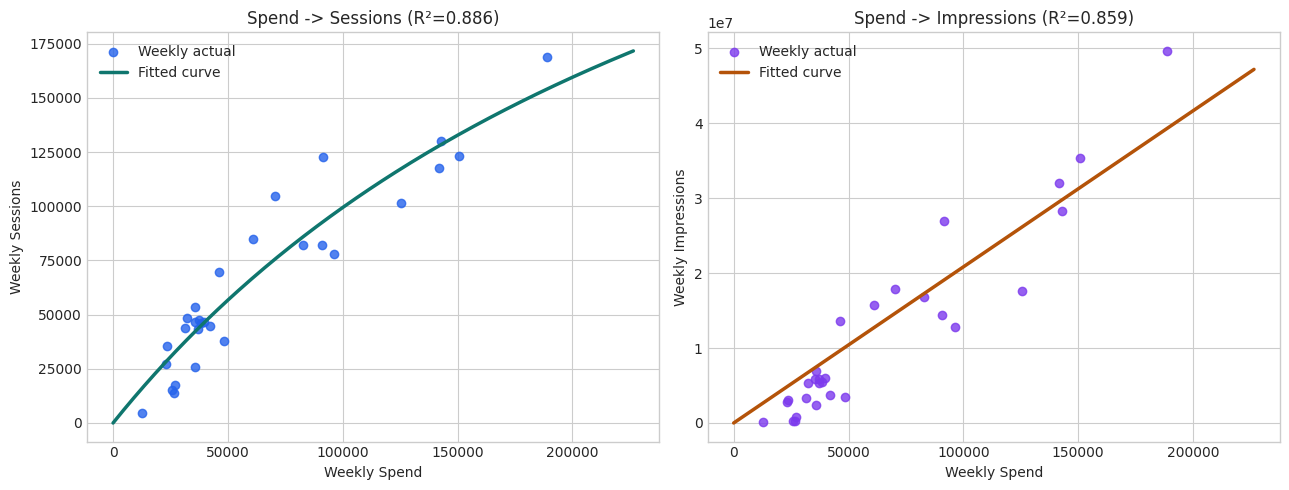

In [ ]:
# --- Plots for explainability ---

x_grid = np.linspace(0, weekly["spend"].max() * 1.2, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(weekly["spend"], weekly["sessions"], alpha=0.8, color="#2563EB", label="Weekly actual")
axes[0].plot(x_grid, sat_curve(x_grid, a_sess, b_sess), color="#0F766E", lw=2.5, label="Fitted curve")
axes[0].set_title(f"Spend -> Sessions (R²={r2_sess:.3f})")
axes[0].set_xlabel("Weekly Spend")
axes[0].set_ylabel("Weekly Sessions")
axes[0].legend(frameon=False)

axes[1].scatter(weekly["spend"], weekly["impressions"], alpha=0.8, color="#7C3AED", label="Weekly actual")
axes[1].plot(x_grid, sat_curve(x_grid, a_impr, b_impr), color="#B45309", lw=2.5, label="Fitted curve")
axes[1].set_title(f"Spend -> Impressions (R²={r2_impr:.3f})")
axes[1].set_xlabel("Weekly Spend")
axes[1].set_ylabel("Weekly Impressions")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# --- Weekly budget table preview and export-ready dataframe ---

weekly_budget_table = weekly[
    [
        "week_label",
        "spend",
        "sessions",
        "impressions",
        "required_sessions_wk",
        "required_impressions_wk",
        "req_spend_from_sessions",
        "req_spend_from_impressions",
    ]
].copy()

weekly_budget_table = weekly_budget_table.rename(
    columns={
        "spend": "proxy_spend_actual",
        "sessions": "proxy_sessions_actual",
        "impressions": "proxy_impressions_actual",
        "required_sessions_wk": "required_sessions_target",
        "required_impressions_wk": "required_impressions_target",
        "req_spend_from_sessions": "estimated_spend_from_sessions_curve",
        "req_spend_from_impressions": "estimated_spend_from_impressions_curve",
    }
)

weekly_budget_table.head(12)

,week_label,proxy_spend_actual,proxy_sessions_actual,proxy_impressions_actual,required_sessions_target,required_impressions_target,estimated_spend_from_sessions_curve,estimated_spend_from_impressions_curve
0,CW 24,12707.583926,4482,75448,2.224983e+05,4.954635e+05,3.760783e+05,2378.989455
1,CW 25,26549.859460,14011,205910,6.955428e+05,1.352201e+06,5.838734e+08,6492.653469
2,CW 26,25679.899478,15081,211969,7.486605e+05,1.391991e+06,6.844884e+08,6683.702896
3,CW 27,26975.348799,17473,780772,8.674056e+05,5.127294e+06,9.094146e+08,24618.921124
4,CW 28,35824.279049,25805,2426763,1.281028e+06,1.593644e+07,1.692895e+09,76519.505507
5,CW 29,48392.531388,37844,3469639,1.878676e+06,2.278496e+07,2.824955e+09,109402.962669
6,CW 30,42043.039699,44978,3697549,2.232826e+06,2.428163e+07,3.495785e+09,116589.309624
7,CW 31,31375.633021,43735,3272967,2.171120e+06,2.149342e+07,3.378902e+09,103201.597106
8,CW 32,23694.902299,35491,3116913,1.761866e+06,2.046862e+07,2.603696e+09,98280.978513
9,CW 33,22999.777515,27202,2787523,1.350379e+06,1.830554e+07,1.824259e+09,87894.813758


In [ ]:
# --- Simple target calculator (edit variables below) ---
# You can overwrite these two inputs directly.

target_sessions_annual = annual_required_sessions      # e.g. 92527054.80
target_impressions_annual = annual_required_impressions # e.g. ws Y58 value

# Weekly distribution uses historical proxy shares from this notebook.
req_sessions_wk_user = target_sessions_annual * weekly["session_share"]
req_impressions_wk_user = target_impressions_annual * weekly["impression_share"]

est_spend_sessions_user = inverse_sat_with_tail(req_sessions_wk_user, a_sess, b_sess)
est_spend_impressions_user = inverse_sat_with_tail(req_impressions_wk_user, a_impr, b_impr)

print("=== User Target Calculator ===")
print("Target annual sessions:", round(float(target_sessions_annual), 2))
print("Target annual impressions:", round(float(target_impressions_annual), 2))
print("Estimated annual budget (from sessions curve):", round(float(est_spend_sessions_user.sum()), 2))
print("Estimated annual budget (from impressions curve):", round(float(est_spend_impressions_user.sum()), 2))
print("RFL benchmark annual budget (Y60):", round(float(annual_budget_benchmark), 2))

=== User Target Calculator ===
Target annual sessions: 92527054.8
Target annual impressions: 2246789457.86
Estimated annual budget (from sessions curve): 154301696824.41
Estimated annual budget (from impressions curve): 10788057.27
RFL benchmark annual budget (Y60): 9383397.24
